# Proyecto 5: Spaceship Titanic - Ingeniería de Características y Modelado

En este cuaderno prepararemos los datos finales, entrenaremos un modelo de clasificación y lo guardaremos para su uso en la aplicación web.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

sns.set_theme(style="whitegrid")

## 1. Carga y Preprocesamiento de Datos

In [2]:
train_df = pd.read_csv('../data/train.csv')

def preprocess_data(df):
    df = df.copy()
    
    # Extraer información de Cabin: Deck/Num/Side
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df.drop('Cabin', axis=1, inplace=True)
    
    # Imputación de nulos (Estrategia simple)
    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df.select_dtypes(include=['object']).columns
    
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
    
    # Label Encoding para variables categóricas
    le = LabelEncoder()
    for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']:
        df[col] = le.fit_transform(df[col])
    
    # Eliminar columnas no necesarias
    df.drop(['PassengerId', 'Name', 'Num'], axis=1, inplace=True)
    
    return df

train_processed = preprocess_data(train_df)
train_processed.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,0
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,True,5,1
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0,1
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0,1
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,True,5,1


## 2. División de Datos y Entrenamiento del Modelo

In [3]:
X = train_processed.drop('Transported', axis=1)
y = train_processed['Transported'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 3. Evaluación del Modelo

In [4]:
y_pred = model.predict(X_val)

print(f"Precisión en Validación: {accuracy_score(y_val, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred))

Precisión en Validación: 0.7867

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       861
           1       0.77      0.82      0.80       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



## 4. Importancia de Características

C:\Users\frany\AppData\Local\Temp\ipykernel_8196\1365240201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette='viridis')


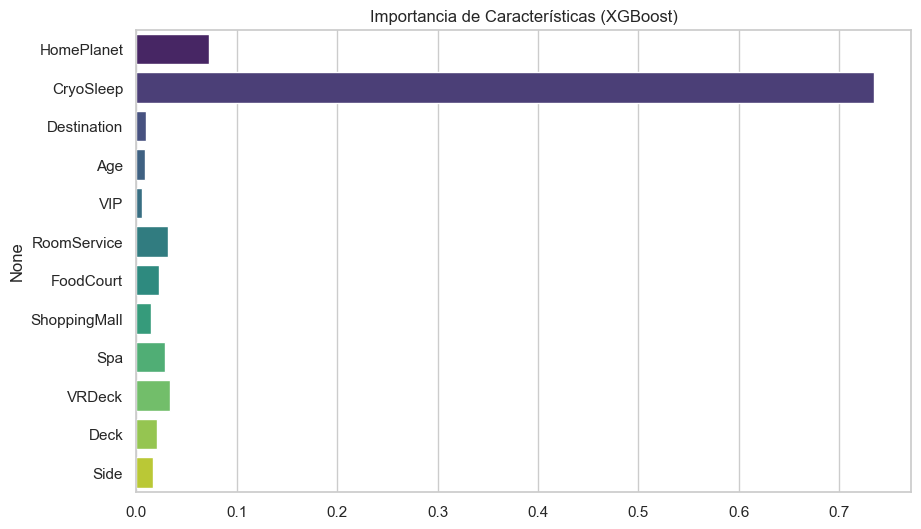

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=model.feature_importances_, y=X.columns, palette='viridis')
plt.title('Importancia de Características (XGBoost)')
plt.show()

## 5. Guardado del Modelo

Guardamos el modelo entrenado en la carpeta `models/` para su uso posterior en la aplicación web.

In [6]:
if not os.path.exists('../models'):
    os.makedirs('../models')

joblib.dump(model, '../models/spaceship_titanic_model.pkl')
print("Modelo guardado exitosamente.")

Modelo guardado exitosamente.
